<a href="https://colab.research.google.com/github/Loicsav/SalasOrtegaConde/blob/main/Entornos_Complejos/DiferenciaTemporal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Metodos Aproximados**

## **1. Preparación del Entorno**

La preparación consta de las siguientes partes:
- **Instalación de Dependencias**: Se instalan las librerías necesarias para utilizar el entorno `gymnasium` para la simulación, con el objetivo de crear un ambiente controlado para que el agente pueda interactuar.
- **Importación de Librerías**: Se importan las bibliotecas necesarias como `numpy` para el manejo de matrices y `matplotlib` para la visualización de los resultados.

- **Importación del Entorno "MountainCar"**:
Se carga la versión del entorno "MountainCar".

#### 3. **Funciones para Mostrar los Resultados**
   - Se define una función para graficar la proporción de recompensas obtenidas en cada episodio del entrenamiento. Esto ayuda a visualizar el progreso del agente en términos de su desempeño durante el entrenamiento.



##### **Código de la Instalación e Importación**
----

%%capture
#@title Instalamos gym
!pip install 'gym[box2d]==0.20.0'

## Instalación de algunos paquetes.
#!apt-get update
## Para usar gymnasium[box2d]
#!apt install swig
#!pip install gymnasium[box2d]


# Instalación de algunos paquetes.
!apt-get update

# Para visualizar en colab https://medium.com/@coldstart_coder/visually-rendering-python-gymnasium-in-jupyter-notebooks-4413e4087a0f
!apt-get install -y python-opengl ffmpeg
!apt-get install --upgrade cmake

# Para usar gymnasium[box2d]
!apt install swig xvfb
!pip install -U  pyvirtualdisplay

!pip install gymnasium gymnasium[box2d]

In [1]:
#@title Importamos librerias
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import gymnasium as gym
import torch
import gc

from src.agents.AgenteDT_SarsaSG import AgenteDT_SarsaSG
from src.agents.AgenteDT_Double_Deep_QL import AgenteDT_DobleDeepQL
from src.agents.AgenteDT_Deep_QL import AgenteDT_DeepQL

from src.tilings.tiling import TileCodingEnv

from src.ploting import *

In [2]:
# Configuración del dispositivo (CPU o GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Liberación de memoria para evitar problemas de consumo en GPU
gc.collect() # Ejecuta el recolector de basura de Python
torch.cuda.empty_cache() # Vacía la caché de memoria en GPU

# Depuración de errores en CUDA
os.environ['CUDA_LAUNCH_BLOCKING'] = '1' # Muestra errores de CUDA en el punto exacto donde ocurren
# Configuración de la semilla para reproducibilidad
seed = 2024 # Se define una semilla fija

# Fijar la semilla en NumPy
np.random.seed(seed) # Para generar números aleatorios consistentes en NumPy
np.random.default_rng(seed) # Establece una instancia del generador de NumPy con la misma semilla

# Fijar la semilla en Python
os.environ['PYTHONHASHSEED'] = str(seed) # Evita variabilidad en hashing de Python

# Fijar la semilla en PyTorch
torch.manual_seed(seed) # Asegura resultados reproducibles en operaciones de PyTorch
if torch.cuda.is_available(): # Si hay GPU disponible
    torch.cuda.manual_seed(seed) # Fija la semilla para la GPU
    torch.backends.cudnn.deterministic = True # Hace las operaciones de CUDNN determinísticas
    torch.backends.cudnn.benchmark = False # Desactiva optimizaciones de CUDNN para evitar variabilidad

Usando dispositivo: cpu


In [12]:
#@title Importamos el lago helado
video_folder = "./videos"  # Asegúrate de que esta ruta coincide con la carpeta donde se guardan los videos
name = 'MountainCar-v0'
render = "rgb_array"
env = gym.make(name, render_mode=render, max_episode_steps=500 )

In [13]:
#@title Generamos 4 mosaicos (tilings) con 20x20 intervalos. Al nuevo espacio lo llamaremos *tcenv*
tilings = 4
bins = np.array([20, 20])
low = env.observation_space.low
high = env.observation_space.high
tcenv = TileCodingEnv(env, bins=bins, low=low, high=high, seed=seed, n=tilings)
print("Se muestran los 4 mosáicos")
tcenv.tilings

Se muestran los 4 mosáicos


[[array([-1.0649961 , -0.9664089 , -0.8678217 , -0.7692344 , -0.67064726,
         -0.57206   , -0.47347277, -0.37488556, -0.27629834, -0.17771113,
         -0.07912391,  0.0194633 ,  0.11805058,  0.21663773,  0.315225  ,
          0.41381216,  0.51239944,  0.6109867 ,  0.70957386], dtype=float32),
  array([-0.05803319, -0.05005461, -0.04207603, -0.03409745, -0.02611887,
         -0.01814029, -0.01016171, -0.00218313,  0.00579545,  0.01377403,
          0.02175261,  0.02973119,  0.03770977,  0.04568835,  0.05366693,
          0.06164551,  0.06962409,  0.07760266,  0.08558124], dtype=float32)],
 [array([-1.0812603 , -0.97939503, -0.87752974, -0.7756644 , -0.6737991 ,
         -0.5719338 , -0.47006845, -0.36820316, -0.26633787, -0.16447258,
         -0.06260729,  0.039258  ,  0.14112341,  0.2429887 ,  0.344854  ,
          0.4467193 ,  0.5485846 ,  0.6504499 ,  0.7523152 ], dtype=float32),
  array([-0.06204324, -0.05381159, -0.04557995, -0.0373483 , -0.02911665,
         -0.020885  , -0.

## **2. Diseño del Agente**

El diseño del agente consta de dos partes: las políticas de toma de decisiones y el algoritmo de aprendizaje. En este cuaderno nos centraremos en algoritmos de **Métodos Aproximados** para espacios de estados continuos.

### **Métodos Aproximados en Aprendizaje por Refuerzo**
Los Métodos Aproximados son técnicas que permiten escalar los algoritmos de aprendizaje por refuerzo a problemas con espacios de estados y acciones grandes o continuos. En lugar de mantener una tabla Q completa, estos métodos utilizan funciones aproximadoras (como características escaladas o redes neuronales) para estimar la función de valor:

$$\hat{V}(s) \approx V(s) \quad \text{o} \quad \hat{Q}(s,a) \approx Q(s,a)$$

En nuestro caso, utilizaremos dos enfoques:
*   **Tile Coding** con Semi-Gradiente: Discretización del espacio continuo mediante mosaicos para SARSA Semi-Gradiente.
*   **Redes Neuronales Profundas**: Aproximación no-lineal del espacio de valores para Deep Q-Learning y Double Deep Q-Learning.

### **Políticas del Agente**
   - **Política epsilon-soft**: Se define una política donde todas las acciones tienen una probabilidad no nula de ser elegidas. Todos los pares estado-acción tienen una probabilidad de selección mínima de $\epsilon/|A|$.
   - **Política epsilon-greedy**: Basada en la política epsilon-soft. El agente tiene una pequeña probabilidad $\epsilon$ de explorar (tomar una acción aleatoria) y una mayor probabilidad $1-\epsilon$ de explotar (tomar la acción que considera mejor según su aproximación actual). Esto permite equilibrar la exploración y la explotación de manera efectiva.
   - **Política greedy**: Selecciona siempre la acción con el mayor valor estimado. Es la usada una vez que el agente "ha aprendido" para evaluar su comportamiento final.

### **Algoritmos Implementados**

#### **1. SARSA Semi-Gradiente (State-Action-Reward-State-Action)**
SARSA Semi-Gradiente es un algoritmo **On-Policy** que combina ideas de Diferencia Temporal con métodos aproximados. Aprende la función de valor de acción $\hat{Q}(s, a)$ para la política de comportamiento actual utilizando características escaladas derivadas del Tile Coding.

La regla de actualización es:
$$w \leftarrow w + \alpha [R_{t+1} + \gamma \hat{Q}(S_{t+1}, A_{t+1}) - \hat{Q}(S_t, A_t)] \nabla \hat{Q}(S_t, A_t)$$

donde $w$ representa los pesos de las características y $\nabla \hat{Q}$ es el gradiente de la función de valor aproximada respecto a sus pesos.

#### **2. Deep Q-Learning (DQL)**
Deep Q-Learning utiliza una red neuronal profunda para aproximar la función de valor de acción óptima $\hat{Q}(s, a; \theta)$. Es un algoritmo **Off-Policy** que permite aprender una política greedy mientras se explora con una política epsilon-greedy.

La regla de actualización utiliza pérdida Mean Squared Error:
$$L(\theta) = \mathbb{E}[(R_{t+1} + \gamma \max_{a'} \hat{Q}(S_{t+1}, a'; \theta^-) - \hat{Q}(S_t, A_t; \theta))^2]$$

donde $\theta^-$ son los pesos de una **red objetivo** (target network) que se actualiza periódicamente para estabilizar el entrenamiento.

#### **3. Double Deep Q-Learning (DDQL)**
Double Deep Q-Learning resuelve el **sesgo de maximización** presente en Deep Q-Learning. Utiliza dos redes neuronales independientes: una para seleccionar la mejor acción y otra para estimar su valor.

La regla de actualización es:
$$L(\theta) = \mathbb{E}[(R_{t+1} + \gamma \hat{Q}(S_{t+1}, \mathop{\mathrm{argmax}}_{a'} \hat{Q}(S_{t+1}, a'; \theta); \theta^-) - \hat{Q}(S_t, A_t; \theta))^2]$$

Esta estrategia desacopla la selección de acciones de su evaluación, reduciendo significativamente la sobreestimación.


#### **Código de las políticas y algoritmo MC**
----------------

In [18]:
#@title Algoritmo de Iteración de Valor versión MC con Políticas epsilon-soft

def diferencia_temporal(tcenv, agente, num_episodes=5000):
    stats = 0.0
    list_stats = []
    all_episode_lengths = [] 
    step_display = max(1, num_episodes // 10)

    for t in tqdm(range(num_episodes)):
        state, info = tcenv.reset(seed=seed)
        done = False
        episode = []
        result_sum  = 0.0
        action = agente.get_action(state, t)
        while not done:
            new_state, reward, done, truncated, _ = tcenv.step(action)
            done = done or truncated
            new_action = agente.get_action(new_state, t)
            # Guardamos el estado, la acción y la recompensa INMEDIATA
            episode.append((state, action, reward))
            agente.update(state, action, reward, new_state, new_action, done)
            result_sum += reward
            state = new_state
            action = new_action

        # Guardamos datos sobre la evolución
        stats += result_sum
        list_stats.append(stats / (t + 1))
        all_episode_lengths.append(len(episode))

        if t % step_display == 0 and t != 0:
            print(f"Episode: {t}, Avg Return: {stats/t:.2f}, Epsilon: {agente.epsilon:.3f}, Alpha: {agente.alpha:.3f}")

    return list_stats, all_episode_lengths


## **3. Experimentación**

En esta sección realizaremos una comparativa exhaustiva de los algoritmos de Métodos Aproximados (SARSA Semi-Gradiente, Deep Q-Learning y Double Deep Q-Learning) en el entorno continuo de MountainCar, utilizando Tile Coding para la discretización del espacio de estados.

### **Metodología Experimental**
Para cada algoritmo (SARSA Semi-Gradiente, Deep Q-Learning y Double Deep Q-Learning), seguiremos el siguiente procedimiento:

1.  **Preparación del Entorno y Discretización**:
    -   El entorno utilizado es **MountainCar-v0**, un problema de control continuo donde el agente debe aprender a conducir un coche en una montaña sin suficiente potencia para subir directamente.
    -   Dado que el espacio de estados es continuo, aplicamos **Tile Coding** para discretizarlo: utilizamos $n=4$ tilings (mosaicos) con bins de $20 \times 20$ intervalos, lo que permite representar eficientemente el espacio continuo mediante una codificación distribuida.

2.  **Entrenamiento**:
    -   Se ejecutará cada algoritmo durante un número fijo de **5,000 episodios**.
    -   Utilizaremos una política **epsilon-greedy** con decaimiento exponencial. Para SARSA Semi-Gradiente iniciaremos con $\epsilon=0.2$ y para Deep QL con $\epsilon=0.3$, valores que disminuirán progresivamente conforme avanza el entrenamiento, favoreciendo la explotación.
    -   El factor de descuento $\gamma$ se fija en 0.99 para dar importancia a las recompensas futuras en este entorno de aprendizaje lento.
    -   Para los algoritmos basados en redes neuronales (Deep QL y Double Deep QL), se actualiza la red objetivo cada 500 pasos para estabilizar el entrenamiento evitando correlaciones en los datos de entrenamiento.

3.  **Visualización y Análisis de Resultados**:
    -   **Proporción de Recompensas**: Gráfica de la media acumulada de recompensas obtenidas ($f(t)=\frac{\sum_{i=1}^t R_i}{t}$). Refleja la estabilidad y velocidad de convergencia del aprendizaje, indicando cuántas veces el agente logra alcanzar la meta.
    -   **Longitud del Episodio**: Gráfica del número de pasos requeridos por episodio. Una disminución indica que el agente aprende estrategias más eficientes para alcanzar la meta.
    -   **Comparativa de Algoritmos**: Análisis lado a lado del comportamiento de los tres métodos aproximados (SARSA SG, Deep QL, Double Deep QL) para identificar cuál converge más rápidamente y logra mejor desempeño.
    -   **Video de demostración**: Generación de GIFs de episodios demostrativos usando la política greedy derivada del aprendizaje para verificar cualitativamente el comportamiento final del agente.

### **3.1 Repressentaciones Gráficas**

Para comprobar el aprendizaje se mostrará la función $f(t)=\frac{\sum_{i=1}^t R_i}{t}$ para $t=1,2,\ldots, NumeroEpisodios$. La justificación es la siguiente. Como sabemmos que el retorno en el estados inicial 1 (pues no hay descuento) o 9, si se divide por el número de episodios ejecutados se calcular el porcentaje de recompensas positivas obtenidas. Dicho de otra forma, nos dirá el porcentaje de veces que el agente ha llegado al estado terminal.


### **3.2 Experimentación en el escenario 4x4**



   - Se realizan 5000 epsisodios y se actualizan los valores Q (valor de acción) basándose en las recompensas obtenidas durante cada episodio completo (e.d. aplicamos Monte Carlo) Se apica una política $\epsilon$ greedy sobre una política $\epsilon$ soft con un valor $\epsilon$ constante




#### **3.2.1 Algoritmo de SARSA Semi-Gradiante**

In [32]:
# @title Aprendizaje
agente_DT_Sarsa_V4 = AgenteDT_SarsaSG(tcenv, seed, discount_factor=0.99, epsilon=0.2, decay=True, num_episodes=5000, decay_rate=200.0)
stats_sarsa, lengths_sarsa = diferencia_temporal(tcenv, agente=agente_DT_Sarsa_V4, num_episodes=5000)

 10%|█         | 507/5000 [00:23<01:50, 40.58it/s]

Episode: 500, Avg Return: -361.98, Epsilon: 0.200, Alpha: 0.422


 20%|██        | 1007/5000 [00:35<01:45, 37.99it/s]

Episode: 1000, Avg Return: -279.17, Epsilon: 0.200, Alpha: 0.279


 30%|███       | 1506/5000 [00:48<01:36, 36.08it/s]

...

 80%|████████  | 4005/5000 [01:38<00:19, 51.10it/s]

Episode: 4000, Avg Return: -189.71, Epsilon: 0.050, Alpha: 0.236


 90%|█████████ | 4505/5000 [01:48<00:10, 49.31it/s]

Episode: 4500, Avg Return: -185.22, Epsilon: 0.044, Alpha: 1.000


100%|██████████| 5000/5000 [01:57<00:00, 42.50it/s]


Mostramos plots

In [34]:
datos_sarsa = {"sarsa": {"stats": stats_sarsa, "lengths": lengths_sarsa}}
save_training_results_to_csv("sarsa_me.csv", datos_sarsa)

Datos de entrenamiento guardados exitosamente en sarsa_me.csv


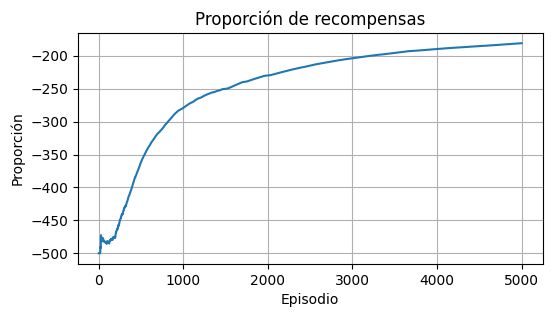

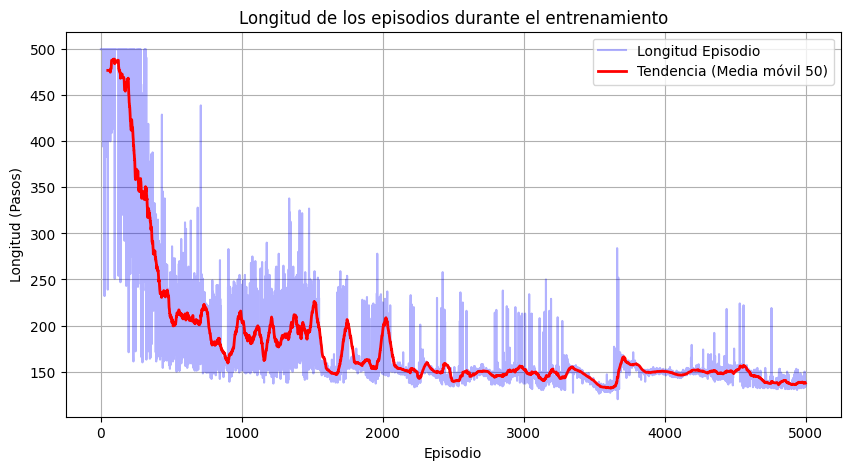

Máxima proporcion: -180.8334


In [33]:
#@title Proporción de aciertos por número de episodios

plot(stats_sarsa)
plot_lengths(lengths_sarsa)
print(f"Máxima proporcion: {stats_sarsa[-1]}")

Mostramos escenario

In [ ]:
# Crear el entorno de CartPole con render_mode configurado para capturar imágenes.
env_demo = gym.make(name, render_mode='rgb_array')
tilings = 4
bins = np.array([20, 20])
low = env_demo.observation_space.low
high = env_demo.observation_space.high
tcenv_demo = TileCodingEnv(env_demo, bins=bins, low=low, high=high, seed=seed, n=tilings)


# Ejecutar un episodio utilizando la política greedy y capturar los fotogramas.
frames = run_episode_greedy(tcenv_demo, agente_DT_Sarsa_V4.action_values_Q, max_steps=500)

# Cerrar el entorno una vez terminado el episodio.
tcenv_demo.close()

# Crear el GIF a partir de los fotogramas capturados.
gif_path = frames_to_gif(frames, filename="cartpole_sarsa.gif")
print("GIF guardado en:", gif_path)

In [ ]:
def display_gif2(gif_path):
    """
    Muestra un GIF en Google Colab.

    Parámetros:
      - gif_path (str): Ruta del archivo GIF.

    Retorna:
      - HTML: Objeto HTML que contiene el GIF incrustado.
    """
    # Abrir el archivo GIF en modo binario.
    with open(gif_path, 'rb') as f:
        video = f.read()
    # Convertir el contenido del GIF a una cadena Base64.
    b64 = base64.b64encode(video)
    # Retornar el objeto HTML que muestra el GIF.
    return HTML(f'<img src="data:image/gif;base64,{b64.decode()}" style="border: 2px solid black;">')
display_gif2(gif_path)

Mostramos video

#### **3.2.1 Algoritmo de Deep Q-Learning**

In [5]:
from tqdm import tqdm

#@title Algoritmo de Iteración de Deep Q-Learning con Redes Neuronales
def entrenamientoDeepQL(tcenv, agente, num_episodes=5000, target_update_freq=500):
    stats = 0.0
    list_stats = []
    all_episode_lengths = [] 
    step_display = max(1, num_episodes // 10)
    
    global_step = 0 # Añadimos un contador global de pasos
    
    for t in tqdm(range(num_episodes)):
        # Asumo que `seed` está definida globalmente en tu script
        state, info = tcenv.reset(seed=seed) 
        done = False
        episode = []
        result_sum  = 0.0
        c = 0
        
        while not done:
            action = agente.get_action(state, t)
            new_state, reward, terminated, truncated, _ = tcenv.step(action)
            done = truncated or terminated
            
            # Guardamos la experiencia
            episode.append((state, action, reward))
            agente.save_experience(state, action, reward, new_state, done)
            
            # --- EL CAMBIO CRÍTICO: ENTRENAR DENTRO DEL BUCLE ---
            # Ahora la red aprende en cada paso (o cuando el batch tenga tamaño suficiente)
            agente.update()
            
            # --- ACTUALIZACIÓN DE RED OBJETIVO POR PASOS ---
            if global_step % target_update_freq == 0 and global_step > 0:
                agente.update_target_network()
            
            result_sum += reward
            state = new_state
            c += 1
            global_step += 1
            
        # Guardamos datos sobre la evolución
        stats += result_sum
        list_stats.append(stats / (t + 1))
        all_episode_lengths.append(len(episode))

        if t % step_display == 0 and t != 0:
            print(f"Episode: {t}, Avg Return: {stats/t:.2f}, Epsilon: {agente.epsilon:.3f}")

    return list_stats, all_episode_lengths

In [ ]:
# @title Aprendizaje
agente_DT_DQL = AgenteDT_DeepQL(tcenv, seed, discount_factor=0.99, epsilon=0.3, decay=True, num_episodes=5000, decay_rate=100.0)
stats_dql, lengths_dql = entrenamientoDeepQL(tcenv, agente=agente_DT_DQL, num_episodes=5000)
agente_DT_DQL.save("pesos_DeepQL.pth")

  0%|          | 0/5000 [00:00<?, ?it/s]

 10%|█         | 501/5000 [06:05<42:54,  1.75it/s]  

Episode: 500, Avg Return: -248.17, Epsilon: 0.200


 20%|██        | 1001/5000 [10:45<31:20,  2.13it/s] 

Episode: 1000, Avg Return: -210.83, Epsilon: 0.100


...

 80%|████████  | 4001/5000 [35:28<09:22,  1.78it/s]

Episode: 4000, Avg Return: -166.04, Epsilon: 0.025


 90%|█████████ | 4501/5000 [39:18<04:21,  1.91it/s]

Episode: 4500, Avg Return: -163.20, Epsilon: 0.022


100%|██████████| 5000/5000 [43:08<00:00,  1.93it/s]


Mostramos graficas

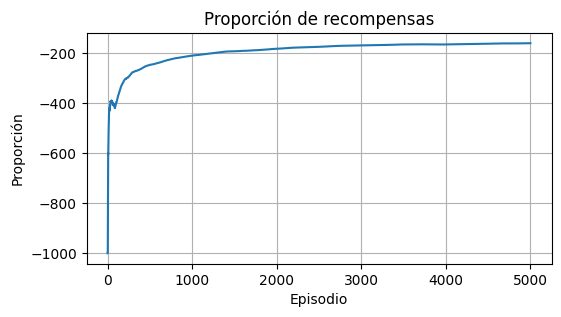

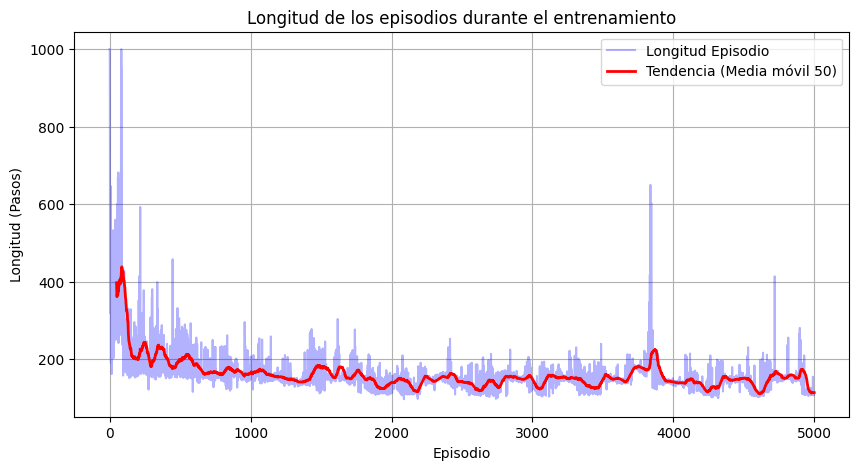

Máxima proporcion: -161.1796


In [ ]:
#@title Proporción de aciertos por número de episodios

plot(stats_dql)
plot_lengths(lengths_dql)
print(f"Máxima proporcion: {stats_dql[-1]}")

Mostramos escenario

In [22]:
# Crear el entorno de CartPole con render_mode configurado para capturar imágenes.
env_demo = gym.make(name, render_mode='rgb_array')
tilings = 4
bins = np.array([20, 20])
low = env_demo.observation_space.low
high = env_demo.observation_space.high
tcenv_demo = TileCodingEnv(env_demo, bins=bins, low=low, high=high, seed=seed, n=tilings)


# Ejecutar un episodio utilizando la política greedy y capturar los fotogramas.
frames = run_episode_greedy(tcenv_demo, agente_DT_DQL.targetNetwork, seed=seed, max_steps=500, tipo_algoritmo="QNetwork", device=agente_DT_DQL.device)

# Cerrar el entorno una vez terminado el episodio.
tcenv_demo.close()

# Crear el GIF a partir de los fotogramas capturados.
gif_path = frames_to_gif(frames, filename="cartpole_ql.gif")
print("GIF guardado en:", gif_path)

GIF guardado en: cartpole_ql.gif



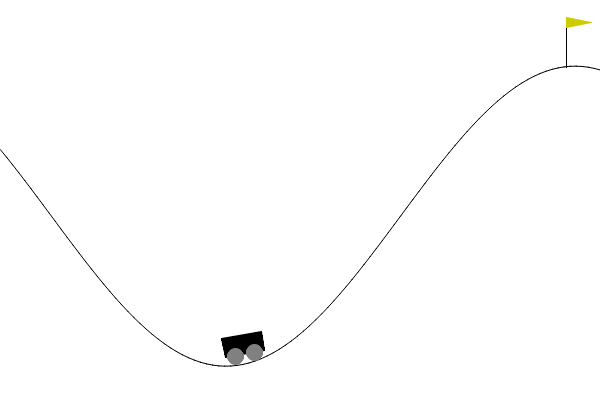

In [23]:
display_gif(gif_path)

#### **3.2.1 Algoritmo de Doble Deep Q-Learning**

In [ ]:
# @title Aprendizaje
agente_DT_DDQL = AgenteDT_DobleDeepQL(tcenv, seed, discount_factor=0.99, epsilon=0.3, decay=True, num_episodes=5000, decay_rate=100.0)
stats_ddql, lengths_ddql = entrenamientoDeepQL(tcenv, agente=agente_DT_DDQL, num_episodes=5000)
agente_DT_DDQL.save_model("pesos_DoubleDeepQL.pth")

KeyboardInterrupt: 

Mostramos graficas

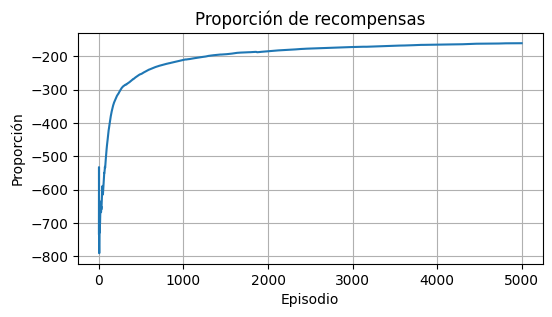

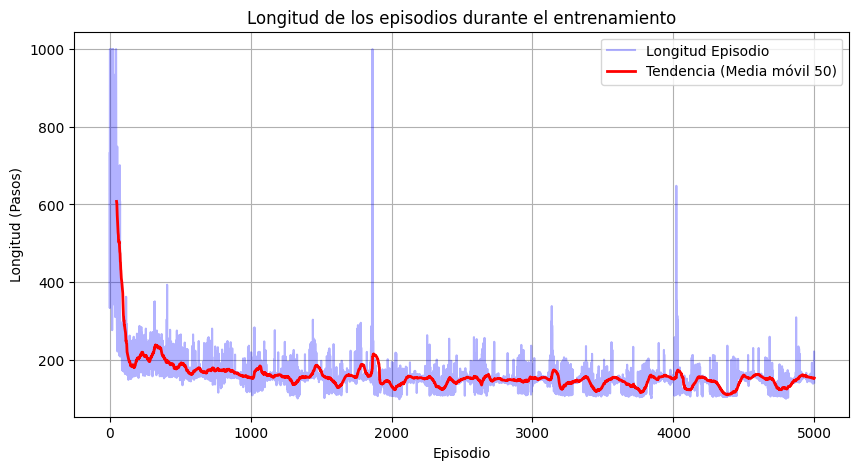

Máxima proporcion: -160.6248


In [ ]:
#@title Proporción de aciertos por número de episodios

plot(stats_ddql)
plot_lengths(lengths_ddql)
print(f"Máxima proporcion: {stats_ddql[-1]}")

Mostramos escenario

In [36]:
# Crear el entorno de CartPole con render_mode configurado para capturar imágenes.
env_demo = gym.make(name, render_mode='rgb_array')
tilings = 4
bins = np.array([20, 20])
low = env_demo.observation_space.low
high = env_demo.observation_space.high
tcenv_demo = TileCodingEnv(env_demo, bins=bins, low=low, high=high, seed=seed, n=tilings)


# Ejecutar un episodio utilizando la política greedy y capturar los fotogramas.
frames = run_episode_greedy(tcenv_demo, agente_DT_DDQL.qNetwork, seed=seed, max_steps=1000, tipo_algoritmo="QNetwork", device=agente_DT_DDQL.device)

# Cerrar el entorno una vez terminado el episodio.
tcenv_demo.close()

# Crear el GIF a partir de los fotogramas capturados.
gif_path = frames_to_gif(frames, filename="cartpole_ddql.gif")
print("GIF guardado en:", gif_path)

GIF guardado en: cartpole_ddql.gif



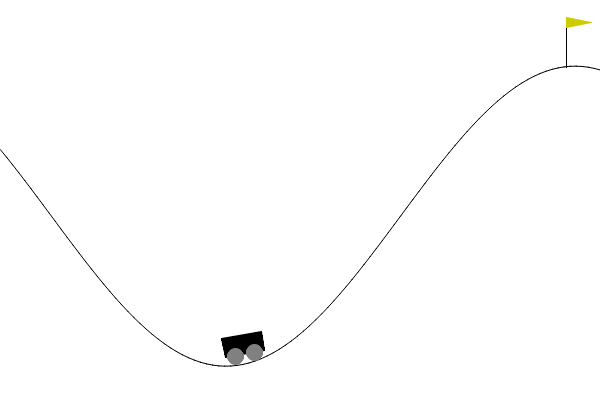

In [35]:
display_gif(gif_path)

In [ ]:
# Guardar resultados de todos los entrenamientos en un CSV para comparativa posterior
# Asegúrate de haber ejecutado todos los entrenamientos anteriores
try:
    results_all = {
        'Semi-Gradient SARSA': {'stats': stats_sarsa, 'lengths': lengths_sarsa},
        'Deep Q-Learning': {'stats': stats_dql, 'lengths': lengths_dql},
        'Double Deep Q-Learning': {'stats': stats_ddql, 'lengths': lengths_ddql}
    }
    
    # Intentamos usar la función de src.ploting.
    # Si no se encuentra (porque el módulo no se ha recargado), la definimos in-line o avisamos
    if 'save_training_results_to_csv' in globals():
        save_training_results_to_csv("resultados_metodos_aproximados.csv", results_all)
    else:
        # Intento de recarga dinámica por si acaso
        import importlib
        import src.ploting
        importlib.reload(src.ploting)
        from src.ploting import save_training_results_to_csv
        save_training_results_to_csv("resultados_metodos_aproximados.csv", results_all)

except NameError as e:
    print(f"No se pudieron guardar los resultados completos. Faltan variables: {e}")
    print("Asegúrate de ejecutar las celdas de entrenamiento de SARSA, Deep QL y Double Deep QL.")

## **4. Análisis y Estudios Futuros**

### **4.1 Análisis de Resultados**


### **4.2 Propuestas para Estudios Futuros**

